In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['font.family'] = 'Arial'

from func_data_prep import process_string
from func_modeling import calculate_vif, run_all_diagnostics, try_transformations, recommend_transformation, back_transform_effects
from statsmodels.formula.api import mixedlm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load Metadata

In [2]:
meta = pd.read_csv("../data/meta_meal_patterns.csv")

meta["HEI_Quartile"] = pd.Categorical(
    meta["HEI_Quartile"], categories=["Q1", "Q2", "Q3", "Q4"], ordered=True
)
meta["bmi_cat"] = pd.Categorical(
    meta["bmi_cat"],
    categories=["Underweight", "Normal", "Overweight", "Obese"],
    ordered=True,
)
meta["age_group_2"] = pd.Categorical(
    meta["age_group_2"], categories=["<35", "35-50", ">50"], ordered=True
)

## Load Merged Meals Data

In [3]:
merged_meals_with_meta = pd.read_pickle("../data/merged_meals_with_meta.pkl")

# #merged_meals['eatean_at'] = pd.to_datetime(merged_meals['eaten_at'])
# merged_meals['eaten_date'] = merged_meals['eaten_at'].dt.date

# # Extract the hour from 'local_eaten_at'
# merged_meals['eaten_hour'] = merged_meals['local_eaten_at'].dt.hour

print(merged_meals_with_meta.shape)

(65838, 204)


## Mixed Model for iAUC

In [4]:
target_col = "iAUC_shifted"

##############################################################################
model_data = merged_meals_with_meta[merged_meals_with_meta["energy_kcal_eaten"] > 0]
model_data = model_data[model_data["eaten_quantity_in_gram"] >= 0]
model_data = model_data[model_data["iAUC_shifted"] >= 0]
model_data = model_data.rename(
    columns={
        "iAUC_-4": "iAUC_past4hr",
        "iAUC_-1": "iAUC_past1hr",
        "iAUC_-2": "iAUC_past2hr",
    }
)
# model_data = model_data.dropna(subset=['iAUC_past4hr'])
model_data = model_data.dropna(subset=["iAUC_past4hr", "iAUC_past1hr", "iAUC_past2hr"])

time_since_last_eaten = model_data.groupby("subject_key")["eaten_at"].apply(
    lambda x: x.diff()
)
model_data = model_data.assign(time_since_last_eaten=time_since_last_eaten.values)
model_data["time_since_last_eaten"] = (
    model_data["time_since_last_eaten"].dt.total_seconds() / 3600
)
model_data = model_data.dropna(subset=["time_since_last_eaten"])

## Removing Standardised Meals
model_data = model_data[
    ~(model_data["combined_name"].apply(lambda x: "Tag standardised meal" in x))
]
# model_data = model_data[(model_data["time_since_last_eaten"] < pd.Timedelta(days=1))]

In [5]:
## Note: adding interaction between meal_type and carb_eaten raises VIF > 5 for them
# formula = f"{target_col} ~ C(meal_type, Treatment(reference='Breakfast'))*carb_eaten + prev_1hr_carb_eaten + prev_2hr_carb_eaten + prev_3hr_carb_eaten + prev_6hr_carb_eaten + prev_12hr_carb_eaten + time_since_last_eaten + iAUC_past4hr + iAUC_past1hr + iAUC_past2hr + age + bmi + carb_eaten + protein_eaten + fat_eaten + alcohol_eaten + C(gender, Treatment(reference='female'))"
formula = f"{target_col} ~ C(meal_type, Treatment(reference='Breakfast'))*carb_eaten + prev_1hr_carb_eaten + prev_2hr_carb_eaten + prev_3hr_carb_eaten + prev_6hr_carb_eaten + prev_12hr_carb_eaten + time_since_last_eaten + iAUC_past4hr + iAUC_past1hr + iAUC_past2hr + age + bmi + carb_eaten + protein_eaten + fat_eaten + alcohol_eaten + C(gender, Treatment(reference='female'))"


model = mixedlm(formula, model_data, groups="subject_key").fit()

# Display model summary
print(model.summary())

print(calculate_vif(formula, model_data))

                                        Mixed Linear Model Regression Results
Model:                                 MixedLM                    Dependent Variable:                    iAUC_shifted
No. Observations:                      58406                      Method:                                REML        
No. Groups:                            962                        Scale:                                 3425.4454   
Min. group size:                       10                         Log-Likelihood:                        -321739.4801
Max. group size:                       169                        Converged:                             Yes         
Mean group size:                       60.7                                                                          
---------------------------------------------------------------------------------------------------------------------
                                                                         Coef.  Std.Err.    z   

In [6]:
formula_template = "{} ~ C(meal_type, Treatment(reference='Breakfast'))*carb_eaten + prev_1hr_carb_eaten + prev_2hr_carb_eaten + prev_3hr_carb_eaten + prev_6hr_carb_eaten + prev_12hr_carb_eaten + time_since_last_eaten + iAUC_past4hr + iAUC_past1hr + iAUC_past2hr + age + bmi + carb_eaten + protein_eaten + fat_eaten + alcohol_eaten + C(gender, Treatment(reference='female'))"

=== Model Diagnostics ===

1. Residual Normality Test
--------------------------


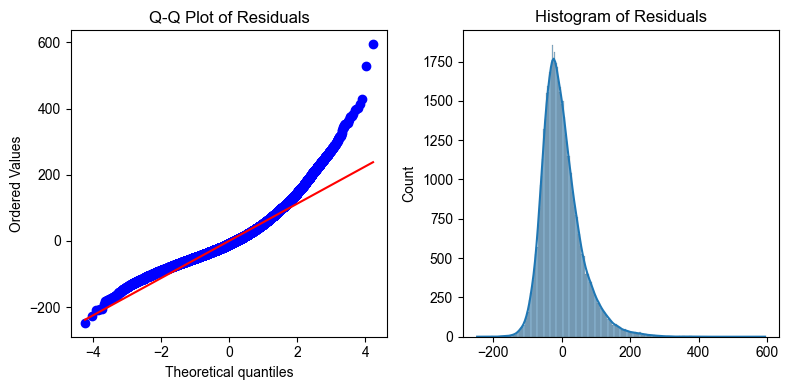

D'Agostino-Pearson test p-value: 0.0000
Interpretation: Residuals deviate from normality

2. Homoscedasticity Test
------------------------


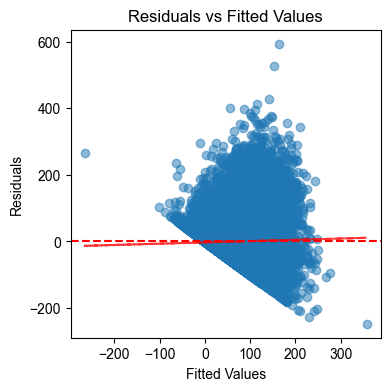

Breusch-Pagan test p-value: 0.0000
Interpretation: Heteroscedasticity present

3. Random Effects Distribution Test
---------------------------------


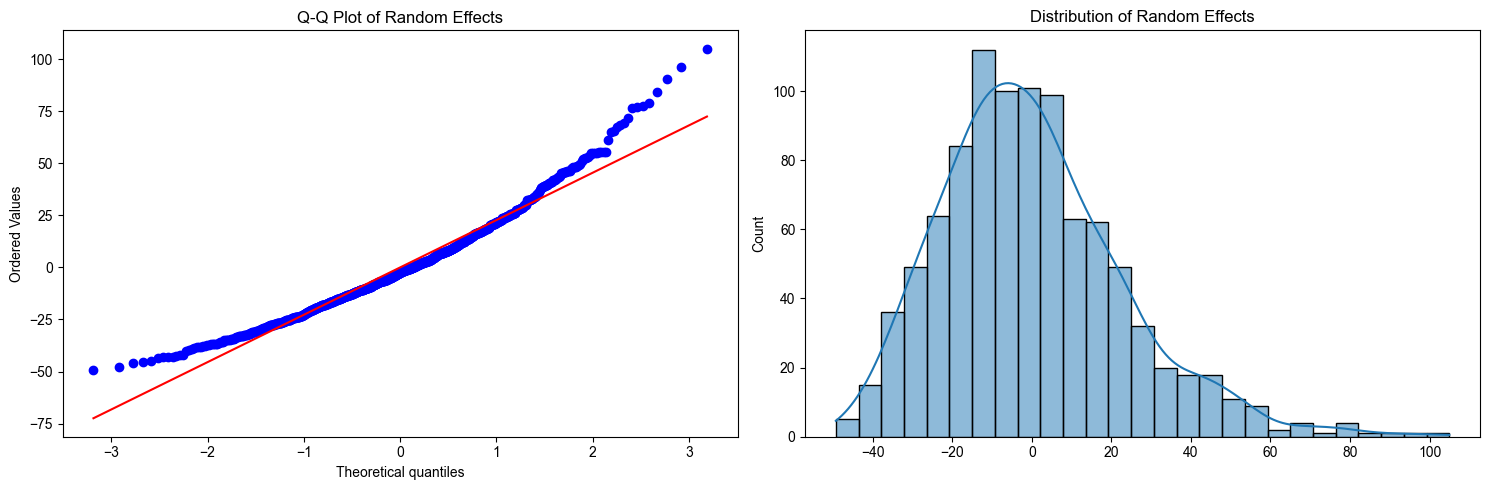

Shapiro-Wilk test p-value: 0.0000
Interpretation: Random effects deviate from normality



{'normality': {'statistic': 12613.449124881336,
  'p_value': 0.0,
  'interpretation': 'Residuals deviate from normality'},
 'homoscedasticity': {'statistic': 1526.6548589862957,
  'p_value': 5.8099794321968e-310,
  'interpretation': 'Heteroscedasticity present'},
 'random_effects': {'statistic': 0.9656474230360859,
  'p_value': 2.7914991788631986e-14,
  'interpretation': 'Random effects deviate from normality'}}

In [7]:
run_all_diagnostics(model)

In [8]:
formula_template

"{} ~ C(meal_type, Treatment(reference='Breakfast'))*carb_eaten + prev_1hr_carb_eaten + prev_2hr_carb_eaten + prev_3hr_carb_eaten + prev_6hr_carb_eaten + prev_12hr_carb_eaten + time_since_last_eaten + iAUC_past4hr + iAUC_past1hr + iAUC_past2hr + age + bmi + carb_eaten + protein_eaten + fat_eaten + alcohol_eaten + C(gender, Treatment(reference='female'))"

In [9]:
# Try different transformations
results_comparison = try_transformations(
    model_data.copy(), target_col, formula_template
)
print("\nTransformation Comparison:")
print(results_comparison)

# Get recommendation based on normality metrics only
best_trans = recommend_transformation(results_comparison)
print(
    f"\nBased on normality metrics, the {best_trans} transformation appears most appropriate"
)
print(
    f"Skewness after transformation: {results_comparison.loc[best_trans, 'skewness']:.4f}"
)
print(
    f"Kurtosis after transformation: {results_comparison.loc[best_trans, 'kurtosis']:.4f}"
)


Transformation Comparison:
                  aic          bic  log_likelihood  ks_pval  normal_pval  \
original  643427.0890  643651.4683    -321688.5445      0.0       0.0000   
log       193160.7584  193385.1377     -96555.3792      0.0       0.0000   
sqrt      314343.9104  314568.2897    -157146.9552      0.0       0.0001   
boxcox    334916.9853  335141.3647    -167433.4927      0.0       0.0000   

          skewness  kurtosis      scale  
original    1.1600    2.9364  3424.3156  
log        -1.0603    1.3052     1.5495  
sqrt        0.0057    0.0884    12.2632  
boxcox     -0.1684   -0.0099    17.4554  

Based on normality metrics, the sqrt transformation appears most appropriate
Skewness after transformation: 0.0057
Kurtosis after transformation: 0.0884


In [45]:
formula_baseline = """baseline_shifted ~ 
                 time_since_last_eaten + age + bmi + 
                 carb_eaten + protein_eaten + fat_eaten + alcohol_eaten + 
                 C(gender, Treatment(reference='female'))"""

model_baseline = mixedlm(formula_baseline, model_data, groups="subject_key").fit()
model_baseline.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                           Mixed Linear Model Regression Results
============================================================================================
Model:                      MixedLM           Dependent Variable:           baseline_shifted
No. Observations:           58406             Method:                       REML            
No. Groups:                 962               Scale:                        0.4902          
Min. group size:            10                Log-Likelihood:               -63771.4189     
Max. group size:            169               Converged:                    Yes             
Mean group size:            60.7                                                            
--------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                         5.145    0.116  44.521 0.000  4.919  5.372
C(gender, Treatment(reference='female'))[T.male]  0.231    0.035   6.572 0.000  0.162  0.300
time_since_last_eaten                            -0.027    0.001 -35.745 0.000 -0.028 -0.025
age                                               0.008    0.001   5.633 0.000  0.005  0.011
bmi                                              -0.006    0.005  -1.237 0.216 -0.015  0.003
carb_eaten                                       -0.001    0.000  -7.975 0.000 -0.001 -0.001
protein_eaten                                    -0.003    0.000 -11.729 0.000 -0.003 -0.002
fat_eaten                                        -0.001    0.000  -2.983 0.003 -0.001 -0.000
alcohol_eaten                                    -0.001    0.001  -0.932 0.351 -0.002  0.001
subject_key Var                                   0.272    0.019                            
============================================================================================

"""

In [47]:
"""
Mixed-effects linear models were used to analyze the relationship between meal characteristics and glycemic response (iAUC). Due to right-skewed distribution of iAUC values (skewness = 1.19), analyses were performed on square-root transformed data to better meet model assumptions. Results were back-transformed to original scale for interpretation. Models included random intercepts for subjects to account for repeated measurements. To ensure robustness of findings, analyses were also performed on untransformed data (see Supplementary Materials), yielding consistent directional effects.
Key model assumptions were assessed through residual diagnostics. The square root transformation improved residual normality (skewness reduced from 1.19 to 0.01) and homoscedasticity. Given the large sample size (N = 72,259 observations from 970 subjects), some deviation from normality was deemed acceptable per the Central Limit Theorem.
"""

# Create transformed target variable
model_data["iAUC_shifted_sqrt"] = np.sqrt(model_data["iAUC_shifted"])

# Update formula with transformed variable
formula_sqrt = """iAUC_shifted_sqrt ~ C(meal_type, Treatment(reference='Breakfast'))*carb_eaten + baseline_shifted +
                 prev_1hr_carb_eaten + prev_2hr_carb_eaten + prev_3hr_carb_eaten + 
                 prev_6hr_carb_eaten + prev_12hr_carb_eaten + time_since_last_eaten + 
                 iAUC_past4hr + iAUC_past1hr + iAUC_past2hr + age + bmi + 
                 carb_eaten + protein_eaten + fat_eaten + alcohol_eaten + 
                 C(gender, Treatment(reference='female'))"""

# Fit model with transformed data
model_sqrt = mixedlm(formula_sqrt, model_data, groups="subject_key").fit()

# Print summary
print("Model Summary for iAUC_shifted_sqrt (not back-transformed):")
print(model_sqrt.summary())

Model Summary for iAUC_shifted_sqrt (not back-transformed):
                                       Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  iAUC_shifted_sqrt
No. Observations:                    58406                    Method:                              REML             
No. Groups:                          962                      Scale:                               10.2376          
Min. group size:                     10                       Log-Likelihood:                      -152369.5653     
Max. group size:                     169                      Converged:                           Yes              
Mean group size:                     60.7                                                                           
--------------------------------------------------------------------------------------------------------------------
                                            

=== Model Diagnostics ===

1. Residual Normality Test
--------------------------


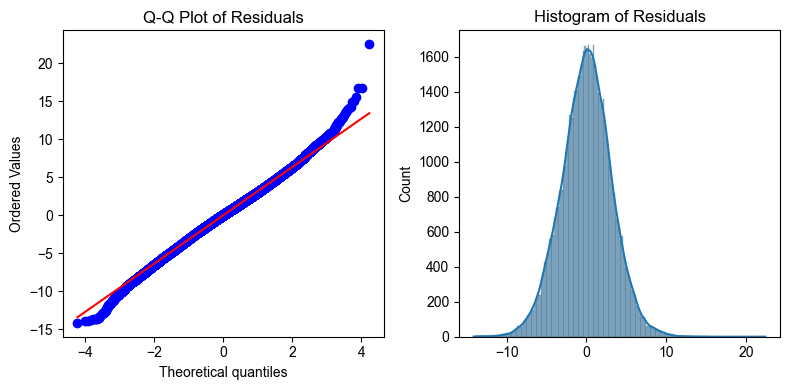

D'Agostino-Pearson test p-value: 0.0000
Interpretation: Residuals deviate from normality

2. Homoscedasticity Test
------------------------


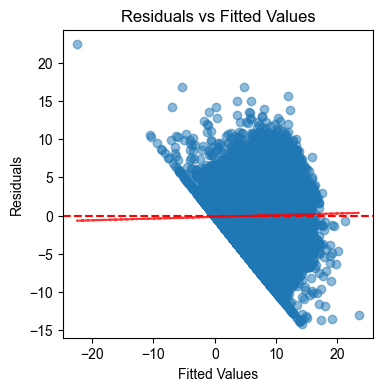

Breusch-Pagan test p-value: 0.0000
Interpretation: Heteroscedasticity present

3. Random Effects Distribution Test
---------------------------------


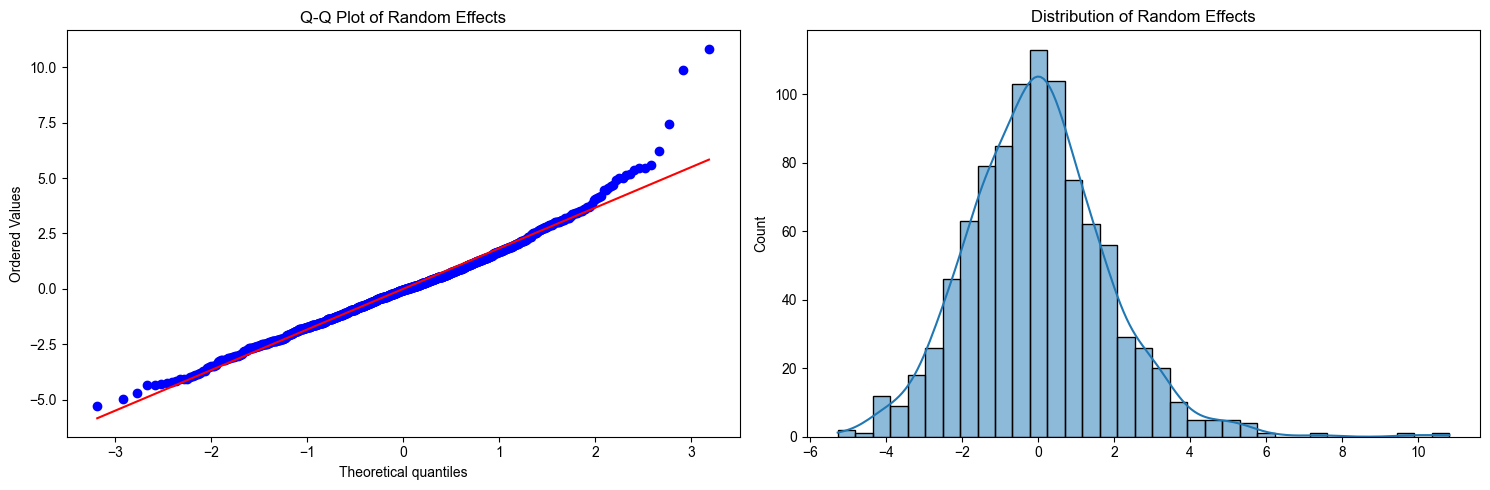

Shapiro-Wilk test p-value: 0.0000
Interpretation: Random effects deviate from normality



{'normality': {'statistic': 334.76984927333484,
  'p_value': 2.0213935542497724e-73,
  'interpretation': 'Residuals deviate from normality'},
 'homoscedasticity': {'statistic': 673.453288590231,
  'p_value': 1.7221842253251033e-127,
  'interpretation': 'Heteroscedasticity present'},
 'random_effects': {'statistic': 0.9778321922812206,
  'p_value': 6.195369884669973e-11,
  'interpretation': 'Random effects deviate from normality'}}

In [35]:
run_all_diagnostics(model_sqrt)

In [36]:
# meal_coef = model_sqrt.params["C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]"]
# meal_se = model_sqrt.bse["C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]"]
# effect, ci_l, ci_u = back_transform_effects(
#     meal_coef,
#     meal_se,
#     eval_point=model_data.groupby("subject_key")["iAUC_shifted_sqrt"].mean().mean(),
# )

# # Could also evaluate at different points
# effect_low = back_transform_effects(
#     meal_coef, meal_se, eval_point=np.percentile(model_data["iAUC_shifted_sqrt"], 25)
# )
# effect_high = back_transform_effects(
#     meal_coef, meal_se, eval_point=np.percentile(model_data["iAUC_shifted_sqrt"], 75)
# )

# print(effect, ci_l, ci_u)
# print(effect_low, effect_high)

In [37]:
# Create a list to store the results
results = []

# Collect the effects and confidence intervals
for var in model_sqrt.params.index:
    effect, ci_l, ci_u = back_transform_effects(
        model_sqrt.params[var],
        model_sqrt.bse[var],
        eval_point=model_data.groupby("subject_key")["iAUC_shifted_sqrt"].mean().mean(),
    )
    results.append(
        {"Variable": var, "Effect": effect, "CI Lower": ci_l, "CI Upper": ci_u}
    )

# Create a DataFrame from the results
effects_df_iAUC = pd.DataFrame(results)

# Display the DataFrame
print("\nEffects on Original Scale (at mean):")
print("-" * 50)
effects_df_iAUC


Effects on Original Scale (at mean):
--------------------------------------------------


,Variable,Effect,CI Lower,CI Upper
0,Intercept,104.497802,99.680581,109.315023
1,"C(meal_type, Treatment(reference='Breakfast'))...",2.298749,1.524816,3.072681
2,"C(meal_type, Treatment(reference='Breakfast'))...",-4.322352,-6.292876,-2.351828
3,"C(meal_type, Treatment(reference='Breakfast'))...",5.817462,5.046795,6.588130
4,"C(gender, Treatment(reference='female'))[T.male]",2.931345,1.520560,4.342129
5,carb_eaten,0.188525,0.176172,0.200879
6,"C(meal_type, Treatment(reference='Breakfast'))...",0.005659,-0.007839,0.019156
7,"C(meal_type, Treatment(reference='Breakfast'))...",0.001746,-0.043943,0.047435
8,"C(meal_type, Treatment(reference='Breakfast'))...",0.008871,-0.004989,0.022731
9,baseline_shifted,-12.797369,-13.040881,-12.553857


In [38]:
effects_df_iAUC["Variable"].values

array(['Intercept',
       "C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]",
       "C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]",
       "C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]",
       "C(gender, Treatment(reference='female'))[T.male]", 'carb_eaten',
       "C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]:carb_eaten",
       "C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]:carb_eaten",
       "C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]:carb_eaten",
       'baseline_shifted', 'prev_1hr_carb_eaten', 'prev_2hr_carb_eaten',
       'prev_3hr_carb_eaten', 'prev_6hr_carb_eaten',
       'prev_12hr_carb_eaten', 'time_since_last_eaten', 'iAUC_past4hr',
       'iAUC_past1hr', 'iAUC_past2hr', 'age', 'bmi', 'protein_eaten',
       'fat_eaten', 'alcohol_eaten', 'subject_key Var'], dtype=object)

In [15]:
# # Create a list to store the results
# results = []

# # Dictionary to map variable names to more readable labels
# label_map = {
#     "Intercept": "Intercept",
#     "C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]": "Meal: Dinner vs Breakfast",
#     "C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]": "Meal: Late Night vs Breakfast",
#     "C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]": "Meal: Lunch vs Breakfast",
#     "C(gender, Treatment(reference='female'))[T.male]": "Gender: Male vs Female",
#     "carb_eaten": "Carbohydrates (g)",
#     "C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]:carb_eaten": "Dinner × Carbohydrates",
#     "C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]:carb_eaten": "Late Night × Carbohydrates",
#     "C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]:carb_eaten": "Lunch × Carbohydrates",
#     "prev_1hr_carb_eaten": "Previous 1hr Carbohydrates",
#     "prev_2hr_carb_eaten": "Previous 2hr Carbohydrates",
#     "prev_3hr_carb_eaten": "Previous 3hr Carbohydrates",
#     "prev_6hr_carb_eaten": "Previous 6hr Carbohydrates",
#     "prev_12hr_carb_eaten": "Previous 12hr Carbohydrates",
#     "time_since_last_eaten": "Time Since Last Meal (min)",
#     "iAUC_past4hr": "Previous 4hr iAUC",
#     "iAUC_past1hr": "Previous 1hr iAUC",
#     "iAUC_past2hr": "Previous 2hr iAUC",
#     "age": "Age (years)",
#     "bmi": "BMI",
#     "protein_eaten": "Protein (g)",
#     "fat_eaten": "Fat (g)",
#     "alcohol_eaten": "Alcohol (g)",
#     "subject_key Var": "Subject Random Effect Variance",
# }

# # Collect the effects and confidence intervals
# for var in model_sqrt.params.index:
#     effect, ci_l, ci_u = back_transform_effects(
#         model_sqrt.params[var],
#         model_sqrt.bse[var],
#         eval_point=model_data.groupby("subject_key")["iAUC_shifted_sqrt"].mean().mean(),
#     )
#     results.append(
#         {
#             "Variable": label_map.get(var, var),
#             "Effect": round(effect, 2),
#             "CI_Lower": round(ci_l, 2),
#             "CI_Upper": round(ci_u, 2),
#             "P_Value": f"{model_sqrt.pvalues[var]:.4f}",
#         }
#     )

# # Create a DataFrame and sort by variable type
# effects_df_iAUC = pd.DataFrame(results)

# # Add significance markers
# effects_df_iAUC["Significance"] = (
#     effects_df_iAUC["P_Value"]
#     .astype(float)
#     .apply(
#         lambda x: (
#             "***"
#             if x < 0.001
#             else "**" if x < 0.01 else "*" if x < 0.05 else "." if x < 0.1 else ""
#         )
#     )
# )

# # Format the effect size and CI as a single string
# effects_df_iAUC["Effect (95% CI)"] = effects_df_iAUC.apply(
#     lambda row: f"{row['Effect']:.2f} ({row['CI_Lower']:.2f}, {row['CI_Upper']:.2f}){row['Significance']}",
#     axis=1,
# )

# # Select and reorder columns for display
# display_df = effects_df_iAUC[["Variable", "Effect (95% CI)", "P_Value"]]

# print("\nEffects on Original Scale (back-transformed):")
# print("=" * 80)
# print(display_df.to_string(index=False))

"The negative association between BMI and glycemic response (β=-0.96 per BMI unit, 95% CI: -1.35, -0.57) appears counterintuitive at first glance. However, further analysis by BMI categories revealed that both overweight (β=-6.94, 95% CI: -10.58, -3.30) and obese individuals (β=-6.42, 95% CI: -12.68, -0.16) had lower baseline glycemic responses compared to normal BMI individuals. Importantly, this baseline difference was moderated by carbohydrate intake, with obese individuals showing enhanced glycemic sensitivity to carbohydrates (β=0.09 per gram, 95% CI: 0.04, 0.14). This suggests that while higher BMI groups may have lower baseline responses, their glycemic control becomes more sensitive to dietary carbohydrates, particularly in obesity. These findings highlight the complex relationship between BMI and glycemic regulation, where baseline differences may mask meal-specific responses."

In [16]:
calculate_vif(formula_sqrt, model_data)

,Variable,VIF
0,Intercept,105.417014
6,"C(meal_type, Treatment(reference='Breakfast'))...",8.617923
5,carb_eaten,8.289535
8,"C(meal_type, Treatment(reference='Breakfast'))...",8.207748
1,"C(meal_type, Treatment(reference='Breakfast'))...",6.783483
3,"C(meal_type, Treatment(reference='Breakfast'))...",6.255591
11,prev_2hr_carb_eaten,3.894748
12,prev_3hr_carb_eaten,3.567652
13,prev_6hr_carb_eaten,2.815017
2,"C(meal_type, Treatment(reference='Breakfast'))...",2.684471


/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_43752/2531495842.py:26: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


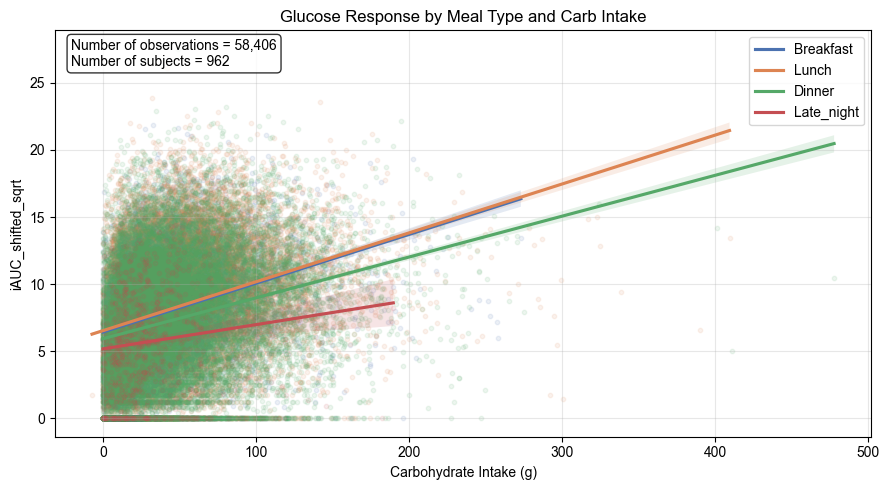

In [17]:
def plot_meal_carb_relationships(data, target_col="iAUC_shifted"):
    # Create figure
    plt.figure(figsize=(9, 5))

    # Create regplot for each meal type
    meals = ["Breakfast", "Lunch", "Dinner", "Late_night"]
    colors = sns.color_palette("deep", len(meals))

    for meal, color in zip(meals, colors):
        meal_data = data[data["meal_type"] == meal]

        # Create regplot
        sns.regplot(
            data=meal_data,
            x="carb_eaten",
            y=target_col,
            scatter_kws={"alpha": 0.1, "s": 10},  # Make points semi-transparent
            line_kws={"label": meal},
            color=color,
        )

    plt.xlabel("Carbohydrate Intake (g)")
    plt.ylabel(target_col)
    plt.title("Glucose Response by Meal Type and Carb Intake")
    plt.legend()
    plt.grid(False, alpha=0.3)

    # Add text box with basic model info
    model_stats = f"Number of observations = {len(data):,}\nNumber of subjects = {len(data['subject_key'].unique()):,}"
    plt.text(
        0.02,
        0.98,
        model_stats,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    plt.tight_layout()
    plt.show()


plot_meal_carb_relationships(model_data, target_col="iAUC_shifted_sqrt")

Macronutrient Effects
Meal Type Effects
Carbohydrate × Meal Interaction Effects
Personal Characteristics
Previous Carb Effects
Previous iAUC Effects


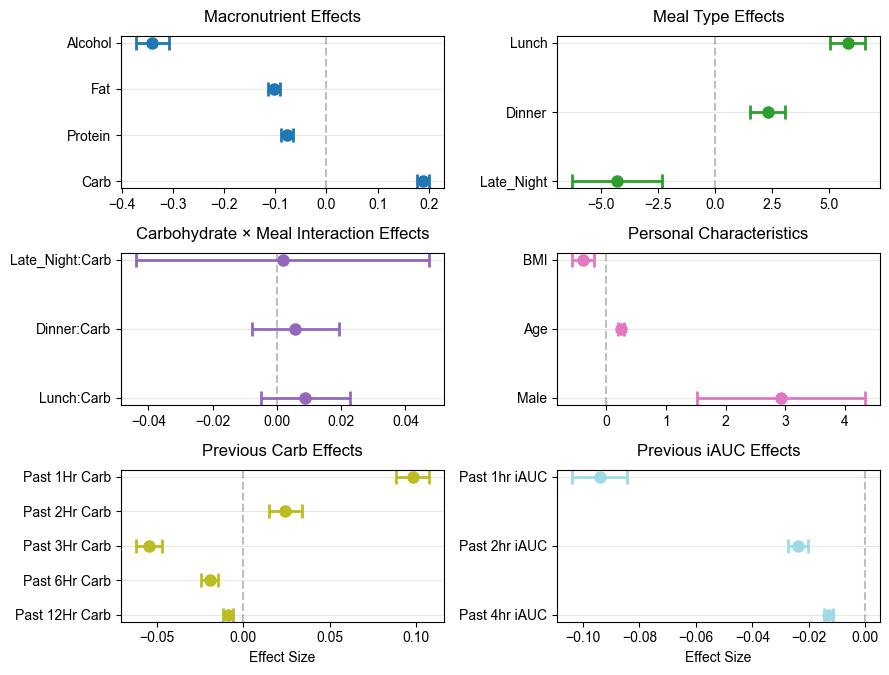

In [406]:
def process_string_for_plotting(s):
    s = s.replace("C(meal_type, Treatment(reference='Breakfast'))[T.", "")
    s = s.replace("]", "")
    s = s.replace("C(gender, Treatment(reference='female'))[T.", "")
    s = s.replace("_eaten", "")

    if s == "bmi":
        return "BMI"
    elif s.startswith("iAUC_"):
        s = s.replace("iAUC_", "")
        s = s.replace("past", "Past ")
        s += " iAUC"
    elif s.startswith("prev_"):
        s = s.replace("prev", "past")
        s = [i.title() for i in s.split("_")]
        s = " ".join(s)
    else:
        s = s.title()
    return s


def plot_confidence_intervals(
    effects_df,
    variable_groups,
    group_labels,
    fig_size=(15, 10),
    n_cols=2,
    colors=None,
    title="Effects with 95% Confidence Intervals",
    xlabel="Effect Size",
    show_reference_line=True,
):
    """
    Create a multi-panel forest plot of confidence intervals.

    Parameters:
    -----------
    effects_df : pandas DataFrame
        DataFrame containing 'Variable', 'Effect', 'CI Lower', 'CI Upper' columns
    variable_groups : list of lists
        List of lists containing variable names for each panel
    group_labels : list
        Labels for each panel
    fig_size : tuple
        Figure size (width, height)
    n_cols : int
        Number of columns in the panel layout
    colors : list
        List of colors for each panel
    title : str
        Main title for the figure
    xlabel : str
        Label for x-axis
    show_reference_line : bool
        Whether to show vertical line at x=0
    """
    # Calculate number of rows needed
    n_rows = int(np.ceil(len(variable_groups) / n_cols))

    # Set up colors if not provided
    if colors is None:
        colors = plt.cm.tab20(np.linspace(0, 1, len(variable_groups)))

    # Create figure and axes
    fig, axes = plt.subplots(n_rows, n_cols, figsize=fig_size)
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = axes.reshape(-1, 1) if n_cols == 1 else axes.reshape(1, -1)

    # Flatten axes for easier iteration
    axes_flat = axes.flatten()

    # Plot each group
    for idx, (variables, label, ax, color) in enumerate(
        zip(variable_groups, group_labels, axes_flat, colors)
    ):
        # Get data for this group
        group_data = effects_df[effects_df["Variable"].isin(variables)].copy()

        # Sort by effect size
        # group_data = group_data.sort_values("Effect")
        print(label)
        if label == "Meal Type Effects":
            group_data = group_data.sort_values(
                by=["Variable"],
                key=lambda x: x.map(
                    {
                        "C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]": 2,
                        "C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]": 1,
                        "C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]": 0,
                    }
                ),
            )
        elif label in ["Previous Carb Effects"]:
            group_data = group_data.sort_values(
                by=["Variable"],
                key=lambda x: x.map(
                    {
                        "prev_1hr_carb_eaten": 4,
                        "prev_2hr_carb_eaten": 3,
                        "prev_3hr_carb_eaten": 2,
                        "prev_6hr_carb_eaten": 1,
                        "prev_12hr_carb_eaten": 0,
                    }
                ),
            )
        else:
            group_data = group_data.sort_values("Effect", ascending=False)

        # Create y-positions
        y_pos = np.arange(len(group_data))

        # Plot
        ax.errorbar(
            group_data["Effect"],
            y_pos,
            xerr=np.abs(
                group_data[["CI Lower", "CI Upper"]].values
                - group_data["Effect"].values.reshape(-1, 1)
            ).T,
            fmt="o",
            color=color,
            capsize=5,
            capthick=2,
            markersize=8,
            elinewidth=2,
        )

        # Add reference line at x=0 if requested
        if show_reference_line:
            ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)

        # Customize appearance
        ax.set_yticks(y_pos)
        # Shorten variable names for better display
        # cleaned_vars = [
        #     v.replace("C(meal_type, Treatment(reference='Breakfast'))[T.", "")
        #     .replace("]", "")
        #     .replace("C(gender, Treatment(reference='female'))[T.", "")
        #     .replace("_eaten", "")
        #     .replace("iAUC_", "iAUC ")
        #     .title()
        #     for v in group_data["Variable"]
        # ]
        cleaned_vars = [process_string_for_plotting(v) for v in group_data["Variable"]]
        ax.set_yticklabels(cleaned_vars, fontsize=10)
        ax.set_title(label, fontsize=12, pad=10)
        # ax.grid(True, alpha=0.3)
        ax.yaxis.grid(True, alpha=0.3)

        # Add x-label only to bottom plots
        if idx >= len(variable_groups) - n_cols:
            ax.set_xlabel(xlabel, fontsize=10)

    # Remove empty subplots if any
    for idx in range(len(variable_groups), len(axes_flat)):
        fig.delaxes(axes_flat[idx])

    # Adjust layout
    plt.suptitle(title, fontsize=14, y=0.99)
    plt.tight_layout()

    return fig, axes


# Define variable groups and their labels
meal_vars = [
    "C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]",
    "C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]",
    "C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]",
]

carb_interaction_vars = [
    "C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]:carb_eaten",
    "C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]:carb_eaten",
    "C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]:carb_eaten",
]

prev_carb_vars = [
    "prev_1hr_carb_eaten",
    "prev_2hr_carb_eaten",
    "prev_3hr_carb_eaten",
    "prev_6hr_carb_eaten",
    "prev_12hr_carb_eaten",
]

prev_iauc_vars = ["iAUC_past1hr", "iAUC_past2hr", "iAUC_past4hr"]

personal_vars = ["age", "bmi", "C(gender, Treatment(reference='female'))[T.male]"]

macro_vars = ["carb_eaten", "protein_eaten", "fat_eaten", "alcohol_eaten"]

variable_groups = [
    macro_vars,
    meal_vars,
    carb_interaction_vars,
    personal_vars,
    prev_carb_vars,
    prev_iauc_vars,
]

group_labels = [
    "Macronutrient Effects",
    "Meal Type Effects",
    "Carbohydrate × Meal Interaction Effects",
    "Personal Characteristics",
    "Previous Carb Effects",
    "Previous iAUC Effects",
]

# Create the plot
fig, axes = plot_confidence_intervals(
    effects_df_iAUC, variable_groups, group_labels, fig_size=(9, 7), n_cols=2, title=""
)
fig.savefig("../images/fig4/iAUC_effects_with_95_CI.png", dpi=300, bbox_inches="tight")

plt.show()

## BMI Categorical Model

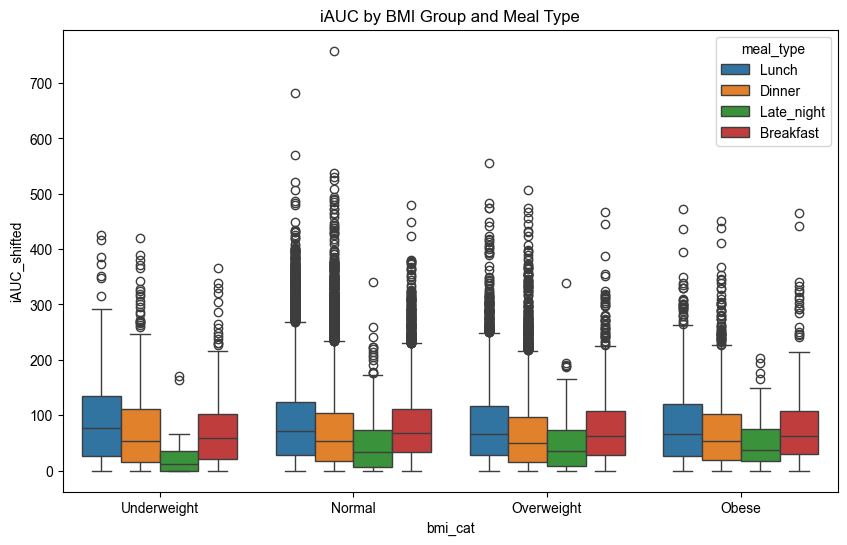


BMI Category Effects (reference: Normal):


,Variable,Effect (95% CI),P_Value
0,"C(bmi_cat, Treatment(reference='Normal'))[T.Un...","-1.23 (-4.84, 2.39)",0.505657
1,"C(bmi_cat, Treatment(reference='Normal'))[T.Ov...","-2.23 (-3.58, -0.89)**",0.001101
2,"C(bmi_cat, Treatment(reference='Normal'))[T.Ob...","-2.75 (-5.05, -0.45)*",0.019015
3,"C(bmi_cat, Treatment(reference='Normal'))[T.Un...","0.06 (0.02, 0.09)**",0.001212
4,"C(bmi_cat, Treatment(reference='Normal'))[T.Ov...","-0.01 (-0.02, 0.01)",0.317073
5,"C(bmi_cat, Treatment(reference='Normal'))[T.Ob...","0.03 (0.01, 0.05)*",0.012857


In [19]:
# Create BMI group model
formula_bmi_cats = """iAUC_shifted_sqrt ~ C(bmi_cat, Treatment(reference='Normal'))*carb_eaten + 
                       C(meal_type, Treatment(reference='Breakfast'))*carb_eaten + 
                       prev_1hr_carb_eaten + prev_2hr_carb_eaten + prev_3hr_carb_eaten + 
                       prev_6hr_carb_eaten + prev_12hr_carb_eaten + time_since_last_eaten + 
                       iAUC_past4hr + iAUC_past1hr + iAUC_past2hr + age + 
                       carb_eaten + protein_eaten + fat_eaten + alcohol_eaten + 
                       C(gender, Treatment(reference='female'))"""

# Fit model
model_bmi_cats = mixedlm(formula_bmi_cats, model_data, groups="subject_key").fit()

# Extract and transform BMI group effects
results = []
for var in model_bmi_cats.params.index:
    if "bmi_cat" in var:
        effect, ci_l, ci_u = back_transform_effects(
            model_bmi_cats.params[var],
            model_bmi_cats.bse[var],
            eval_point=model_data.groupby("subject_key")["iAUC_shifted_sqrt"]
            .mean()
            .mean(),
        )
        results.append(
            {
                "Variable": var,
                "Effect": effect,
                "CI_Lower": ci_l,
                "CI_Upper": ci_u,
                "P_Value": model_bmi_cats.pvalues[var],
            }
        )

# Create DataFrame
bmi_effects = pd.DataFrame(results)

# Add significance markers and format output
bmi_effects["Significance"] = bmi_effects["P_Value"].apply(
    lambda x: (
        "***"
        if x < 0.001
        else "**" if x < 0.01 else "*" if x < 0.05 else "." if x < 0.1 else ""
    )
)

bmi_effects["Effect (95% CI)"] = bmi_effects.apply(
    lambda row: f"{row['Effect']:.2f} ({row['CI_Lower']:.2f}, {row['CI_Upper']:.2f}){row['Significance']}",
    axis=1,
)

# Optional: Visualize mean iAUC by BMI group and meal type
plt.figure(figsize=(10, 6))
sns.boxplot(data=model_data, x="bmi_cat", y="iAUC_shifted", hue="meal_type")
plt.title("iAUC by BMI Group and Meal Type")
plt.show()

print("\nBMI Category Effects (reference: Normal):")
print("=" * 80)
bmi_effects[["Variable", "Effect (95% CI)", "P_Value"]]

In [20]:
bmi_effects["Variable"].unique()

array(["C(bmi_cat, Treatment(reference='Normal'))[T.Underweight]",
       "C(bmi_cat, Treatment(reference='Normal'))[T.Overweight]",
       "C(bmi_cat, Treatment(reference='Normal'))[T.Obese]",
       "C(bmi_cat, Treatment(reference='Normal'))[T.Underweight]:carb_eaten",
       "C(bmi_cat, Treatment(reference='Normal'))[T.Overweight]:carb_eaten",
       "C(bmi_cat, Treatment(reference='Normal'))[T.Obese]:carb_eaten"],
      dtype=object)

In [21]:
model_data[model_data["meal_type"] == "Late_night"][
    [
        "carb_eaten",
        "protein_eaten",
        "fat_eaten",
        "alcohol_eaten",
        "energy_kcal_eaten",
        "time_since_last_eaten",
        "iAUC_shifted",
        "iAUC_past4hr",
        "iAUC_past1hr",
        "iAUC_past2hr",
        "prev_1hr_carb_eaten",
        "prev_2hr_carb_eaten",
        "prev_3hr_carb_eaten",
        "prev_6hr_carb_eaten",
        "prev_12hr_carb_eaten",
    ]
].describe()

,carb_eaten,protein_eaten,fat_eaten,alcohol_eaten,energy_kcal_eaten,time_since_last_eaten,iAUC_shifted,iAUC_past4hr,iAUC_past1hr,iAUC_past2hr,prev_1hr_carb_eaten,prev_2hr_carb_eaten,prev_3hr_carb_eaten,prev_6hr_carb_eaten,prev_12hr_carb_eaten
count,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000
mean,31.648054,9.931796,13.880693,1.740505,309.978697,3.716026,47.766704,78.621348,10.140742,26.886976,6.101006,16.314574,28.986495,77.458026,163.902797
std,26.945787,12.520305,14.438338,5.798023,260.986910,2.936706,50.275573,99.243793,17.126711,41.136185,18.709515,31.641191,40.558180,61.830035,86.898186
min,0.000000,0.000000,0.000000,0.000000,53.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.790000,2.167500,4.880000,0.000000,131.765000,1.699861,7.500000,5.775000,0.000000,0.000000,0.000000,0.000000,0.000000,29.920000,103.620000
50%,24.500000,5.364000,9.800000,0.000000,224.700000,3.046389,33.150000,39.600000,2.775000,10.500000,0.000000,0.000000,11.000000,68.449000,152.245000
75%,43.505000,12.125000,17.716000,0.000000,390.750000,4.792639,72.787500,120.675000,13.425000,35.550000,0.000000,18.120000,44.156500,112.110000,212.840000
max,189.716000,85.440000,98.814000,62.100000,2123.300000,30.108333,339.950000,838.900000,141.525000,327.975000,178.355000,231.469000,231.469000,428.430000,658.807000


In [22]:
model_data[model_data["meal_type"] == "Lunch"][
    [
        "carb_eaten",
        "protein_eaten",
        "fat_eaten",
        "alcohol_eaten",
        "energy_kcal_eaten",
        "time_since_last_eaten",
        "iAUC_shifted",
        "iAUC_past4hr",
        "iAUC_past1hr",
        "iAUC_past2hr",
        "prev_1hr_carb_eaten",
        "prev_2hr_carb_eaten",
        "prev_3hr_carb_eaten",
        "prev_6hr_carb_eaten",
        "prev_12hr_carb_eaten",
    ]
].describe()

,carb_eaten,protein_eaten,fat_eaten,alcohol_eaten,energy_kcal_eaten,time_since_last_eaten,iAUC_shifted,iAUC_past4hr,iAUC_past1hr,iAUC_past2hr,prev_1hr_carb_eaten,prev_2hr_carb_eaten,prev_3hr_carb_eaten,prev_6hr_carb_eaten,prev_12hr_carb_eaten
count,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000,20636.000000
mean,45.446616,19.091351,21.027485,0.495874,462.544206,3.746100,84.970893,95.390180,9.732449,31.361230,8.341282,16.448063,27.739698,65.965317,80.298762
std,35.609304,18.626180,17.918327,2.902989,327.128702,3.789161,73.429701,105.128828,17.667284,46.745575,23.691223,30.554140,36.369676,46.699649,54.322537
min,-7.200000,-5.972000,-4.425000,0.000000,50.200000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.700000,-72.440000,-72.440000
25%,18.156000,4.139000,7.682000,0.000000,193.690000,1.530278,28.125000,10.500000,0.000000,0.000000,0.000000,0.000000,0.000000,37.198750,50.000000
50%,37.400000,13.890000,16.660000,0.000000,404.560000,2.815556,69.025000,63.725000,2.175000,12.000000,0.000000,0.000000,12.518500,56.642500,67.774000
75%,63.731500,28.867000,29.854750,0.000000,650.000000,4.370347,123.000000,144.918750,12.000000,43.650000,0.000000,21.204000,46.790000,88.651750,107.179500
max,409.500000,215.600000,181.230000,62.100000,3428.000000,41.323333,681.525000,1134.550000,390.975000,487.400000,409.500000,420.060000,420.060000,1066.047250,1138.227250


In [23]:
model_data[(model_data["meal_type"] == "Late_night")]["subject_key"].nunique()

383

<Axes: xlabel='meal_type', ylabel='carb_eaten'>

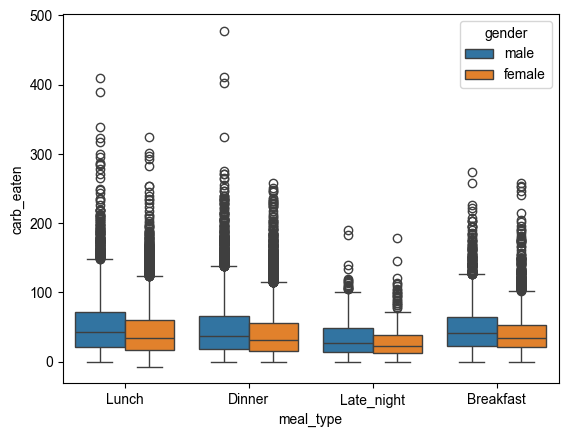

In [24]:
sns.boxplot(data=model_data, x="meal_type", y="carb_eaten", hue="gender")

In [25]:
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests


def plot_boxplot_with_stats(data, x, y, ax=None, title=None):
    """
    Create a boxplot with statistical annotations.

    Parameters:
    -----------
    data : pandas.DataFrame
        Input data
    x : str
        Column name for x-axis categories
    y : str
        Column name for y-axis values
    ax : matplotlib.axes.Axes, optional
        The axes to plot on. If None, current axes will be used
    title : str, optional
        Title for the plot

    Returns:
    --------
    matplotlib.axes.Axes
        The annotated axes
    """
    if ax is None:
        ax = plt.gca()

    # Create boxplot
    sns.boxplot(
        x=x,
        y=y,
        data=data,
        ax=ax,
        palette="Set2",
        width=0.24,
        linewidth=0.5,
        fliersize=2,
    )

    # Get categories and perform global test
    categories = data[x].unique()

    # If only two categories, perform Mann-Whitney U test
    if len(categories) == 2:
        stat, global_p = stats.mannwhitneyu(
            data[data[x] == categories[0]][y],
            data[data[x] == categories[1]][y],
            alternative="two-sided",
        )
    else:
        # Perform Kruskal-Wallis test
        groups = [group[y].values for name, group in data.groupby(x)]
        stat, global_p = stats.kruskal(*groups)

    # Get plot dimensions for annotation positioning
    y_max = data[y].max()
    y_min = data[y].min()
    y_range = y_max - y_min
    spacing = y_range * 0.1

    # Only proceed with pairwise tests if global test is significant
    if global_p < 0.05:
        pairs = list(combinations(categories, 2))
        p_values = []
        effect_sizes = []

        # Perform pairwise comparisons
        for cat1, cat2 in pairs:
            data1 = data[data[x] == cat1][y]
            data2 = data[data[x] == cat2][y]

            statistic, p_value = stats.mannwhitneyu(
                data1, data2, alternative="two-sided"
            )
            p_values.append(p_value)

            # Calculate effect size
            n1, n2 = len(data1), len(data2)
            z_score = statistic - (n1 * n2 / 2)
            z_score = z_score / np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
            effect_size = abs(z_score / np.sqrt(n1 + n2))
            effect_sizes.append(effect_size)

        # Multiple comparison correction
        if len(p_values) > 1:
            rejected, p_values_corrected, _, _ = multipletests(
                p_values, method="fdr_bh"
            )
        else:
            p_values_corrected = p_values
            rejected = [p < 0.05 for p in p_values]

        # Add annotations for significant comparisons
        for idx, ((cat1, cat2), p_value, effect_size, is_sig) in enumerate(
            zip(pairs, p_values_corrected, effect_sizes, rejected)
        ):
            if is_sig:
                x1 = np.where(categories == cat1)[0][0]
                x2 = np.where(categories == cat2)[0][0]
                y = y_max + spacing * (idx + 2) + idx

                p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
                # stat_text = f'{p_text}\nr = {effect_size:.2f}'
                stat_text = f"{p_text}"

                # Add bracket
                ax.plot(
                    [x1, x1, x2, x2],
                    [y - spacing / 0.5, y - 1, y - 1, y - spacing / 0.5],
                    color="black",
                    linewidth=1,
                )
                ax.text(
                    (x1 + x2) / 2,
                    y - spacing,
                    stat_text,
                    ha="center",
                    va="bottom",
                    color="black",
                )

        # Add global test result
        if len(categories) == 2:
            global_text = (
                f"Mann-Whitney U test: p = {global_p:.3f}"
                if global_p >= 0.001
                else "Mann-Whitney U test: p < 0.001"
            )
        else:
            global_text = (
                f"Kruskal-Wallis test: p = {global_p:.3f}"
                if global_p >= 0.001
                else "Kruskal-Wallis test: p < 0.001"
            )
        ax.text(
            len(categories) / 2 - 0.5,
            y + spacing * 1,
            global_text,
            ha="center",
            va="bottom",
            color="black",
            fontweight="normal",
            fontstyle="italic",
        )

        ax.set_ylim(y_min - y_range * 0.1, y_max + spacing * (len(pairs) + 3))
    else:
        ax.set_ylim(y_min - y_range * 0.1, y_max + spacing * 3)

    if title:
        ax.set_title(title)

    return ax

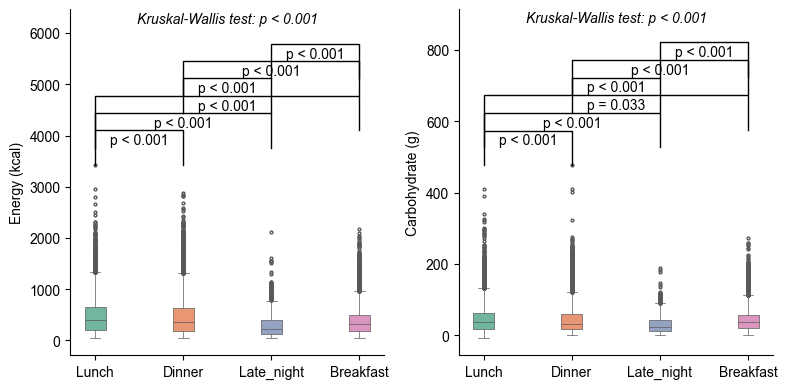

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
ax1 = plot_boxplot_with_stats(
    data=model_data, x="meal_type", y="energy_kcal_eaten", ax=ax[0], title=""
)
ax1.set_ylabel("Energy (kcal)")
ax1.set_xlabel("")

ax2 = plot_boxplot_with_stats(
    data=model_data, x="meal_type", y="carb_eaten", ax=ax[1], title=""
)
ax2.set_ylabel("Carbohydrate (g)")
ax2.set_xlabel("")

sns.despine()
plt.tight_layout()
plt.show()

## savefig
fig.savefig(
    "../images/supplementary/mealtime_energy_carb_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)

## Glucose iAUC Curve Illustration

### Glucose data loading


In [7]:
df_gluc = pd.read_csv("~/Data_Science/data/local_only/df_glucose.csv")
df_gluc.rename(
    columns={"read_at": "time", "user_id": "id", "val": "gl_mmol"}, inplace=True
)

df_gluc["time"] = pd.to_datetime(
    df_gluc["time"], format="%Y-%m-%d %H:%M:%S", errors="coerce"
)
df_gluc = df_gluc.dropna(subset=["time"])

print(df_gluc.shape)
df_gluc.head()

(1883964, 3)


,time,id,gl_mmol
0,2019-11-13 00:31:00,3,6.2
1,2019-11-13 00:46:00,3,6.1
2,2019-11-13 01:01:00,3,5.9
3,2019-11-13 01:16:00,3,5.6
4,2019-11-13 01:31:00,3,4.9


### Plotting glucose curve with meal occurences

user_id: 1609


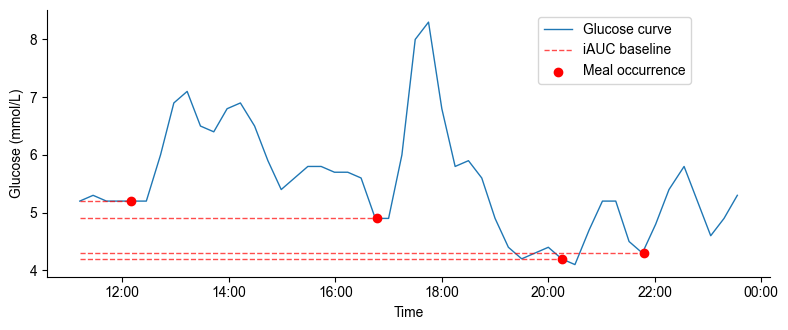

In [479]:
import matplotlib.dates as mdates

user_id = 1609  # np.random.choice(df_gluc["id"].unique())  # 150 640:715 # 2389 200:255 # 1609 220:250

# Make a lineplot with time on x and gl_mmol on y
plot_gluc = df_gluc[df_gluc["id"] == user_id].sort_values(by="time")[200:250]
plot_gluc = plot_gluc.reset_index(drop=True)
plot_gluc["time"] = plot_gluc["time"] + pd.Timedelta(hours=2)

time_extent = (plot_gluc["time"].iloc[0], plot_gluc["time"].iloc[-1])

meal_occurences_df = model_data[
    (model_data["subject_key"] == meta[meta["id"] == user_id]["subject_key"].values[0])
    & (model_data["local_eaten_at"] > time_extent[0])
    & (model_data["local_eaten_at"] < time_extent[1])
    & (model_data["carb_eaten"] > 5)
]

meal_occurences = meal_occurences_df["local_eaten_at"].values  # + pd.Timedelta(hours=1)

plt.figure(figsize=(8, 3.4))
plt.plot(
    plot_gluc["time"],
    plot_gluc["gl_mmol"],
    label="Glucose curve",
    linestyle="-",
    markersize=2,
    linewidth=1,
)

# Keep handles for legend for red lines and dots
baseline_handles = []
dot_handles = []

for i, meal_time in enumerate(meal_occurences):
    meal_time = pd.to_datetime(meal_time)
    # plt.axvline(meal_time, color="black", linestyle=":", alpha=0.7, linewidth=1)

    # Draw a horizontal line at the intersection of the meal (vertical) and the glucose curve
    nearest_idx = (plot_gluc["time"] - meal_time).abs().idxmin()
    intersect_y = plot_gluc.loc[nearest_idx, "gl_mmol"]
    # Only add label on first occurrence
    h1 = plt.hlines(
        y=intersect_y,
        xmin=plot_gluc.loc[0, "time"],
        xmax=meal_time,
        color="red",
        linestyle="--",
        alpha=0.7,
        linewidth=1,
        label="iAUC baseline" if i == 0 else "",
    )
    baseline_handles.append(h1)
    h2 = plt.scatter(
        [meal_time],
        [intersect_y],
        color="red",
        zorder=5,
        label="Meal occurrence" if i == 0 else "",
    )
    dot_handles.append(h2)

print("user_id:", user_id)

plt.xlabel("Time")
plt.ylabel("Glucose (mmol/L)")

# Add legend to explain red baselines and red dots
plt.legend(loc="upper right", frameon=True, bbox_to_anchor=(0.9, 1))

# Format the x-axis to show only hours and minutes, not date
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# plt.xticks(rotation=45)

plt.tight_layout()
sns.despine()

plt.savefig(
    "../images/fig4/iAUC_illustration.png",
    dpi=300,
    bbox_inches="tight",
)

In [477]:
print(meal_occurences_df["carb_eaten"])
print(meal_occurences_df["combined_name"].values)

40245    138.825
40246     43.800
40247     61.983
40248      2.120
40249     22.950
Name: carb_eaten, dtype: float64
["['Feta' 'Pumpkin seeds' 'Spring onion / scallion' 'Eggplant'\n 'Betty Bossi Sweet peppers'\n 'High protein pasta (made of lentils, peas, ...)'\n 'Salad, leaf / salad, green' 'Salad dressing' 'Cremeschnitten'\n 'White coffee, with caffeine']"
 "['Desperados - Beer Tequila' 'Migros - Farm Chips Rosmarin']"
 '[\'Salad dressing\' \'unknown\' \'Salad, leaf / salad, green\'\n \'Taboulé, prepared, with couscous\' \'Pasta, twist\' \'Feta\'\n \'Green asparagus\' "REINE DIJON Moutarde à l\'Ancienne"\n \'Green bean, steamed, without addition of salt\' \'Bread, olive\']'
 "['Salad dressing' 'Salad, leaf / salad, green']"
 "['Beer  n.s.' 'Midor Petit beurre with milk chocolate'\n 'White coffee, with caffeine']"]


In [389]:
meal_occurences_df

,subject_key,eaten_at,local_eaten_at,food_id,dish_id,combined_name,eaten_unit,eaten_quantity_in_gram,water,dairy_products_meat_fish_eggs_tofu_x,...,mean_quantidd_kcal,mean_mfad_jaccard_kcal,eo_freq,eo_space,Breakfast_skip_ratio,Lunch_skip_ratio,Dinner_skip_ratio,Late_night_skip_ratio,time_since_last_eaten,iAUC_shifted_sqrt
40245,m4h3vm,2021-05-26 10:09:33,2021-05-26 12:09:33,[ 1294 1206 1111 1055 16232 8730 1040 27...,[230596 230609 230615 230619],['Feta' 'Pumpkin seeds' 'Spring onion / scalli...,['g' 'dl'],561.0,542.5,30.0,...,0.894541,21.293156,5.384615,2.924736,0.0,0.0,0.0,1.0,5.610833,9.741663
40246,m4h3vm,2021-05-26 14:46:43,2021-05-26 16:46:43,[10069 7800],[230728 230730],['Desperados - Beer Tequila' 'Migros - Farm Ch...,['dl' 'g'],560.0,99.2,0.0,...,0.894541,21.293156,5.384615,2.924736,0.0,0.0,0.0,1.0,4.619444,13.275918
40247,m4h3vm,2021-05-26 18:15:39,2021-05-26 20:15:39,[ 2741 12423 1040 2967 1506 1294 1123 39...,[230812 230813],"['Salad dressing' 'unknown' 'Salad, leaf / sal...",['dl' 'g'],549.0,635.5,115.0,...,0.894541,21.293156,5.384615,2.924736,0.0,0.0,0.0,1.0,3.482222,7.858117
40248,m4h3vm,2021-05-26 18:48:40,2021-05-26 20:48:40,[2741 1040],[230839],"['Salad dressing' 'Salad, leaf / salad, green']",['dl' 'g'],70.0,157.6,0.0,...,0.894541,21.293156,5.384615,2.924736,0.0,0.0,0.0,1.0,0.550278,9.851396
40249,m4h3vm,2021-05-26 19:48:20,2021-05-26 21:48:20,[2634 6429 2521],[230861 230863 230873],['Beer n.s.' 'Midor Petit beurre with milk ch...,['dl' 'g'],325.0,193.0,0.0,...,0.894541,21.293156,5.384615,2.924736,0.0,0.0,0.0,1.0,0.994444,9.967447


user_id: 1609


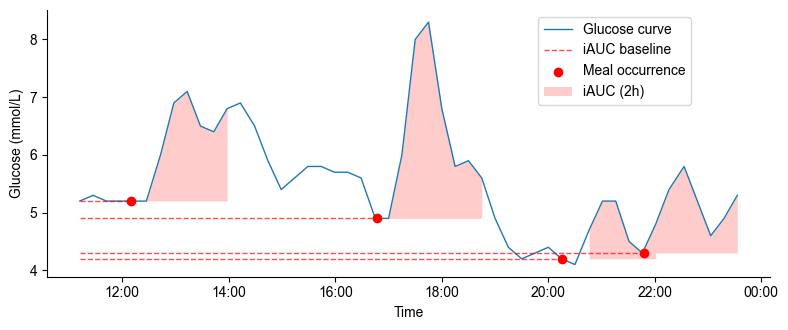

In [491]:
import matplotlib.dates as mdates

user_id = 1609  # np.random.choice(df_gluc["id"].unique())  # 150 640:715 # 2389 200:255 # 1609 220:250

# Make a lineplot with time on x and gl_mmol on y
plot_gluc = df_gluc[df_gluc["id"] == user_id].sort_values(by="time")[200:250]
plot_gluc = plot_gluc.reset_index(drop=True)
plot_gluc["time"] = plot_gluc["time"] + pd.Timedelta(hours=2)

time_extent = (plot_gluc["time"].iloc[0], plot_gluc["time"].iloc[-1])

meal_occurences_df = model_data[
    (model_data["subject_key"] == meta[meta["id"] == user_id]["subject_key"].values[0])
    & (model_data["local_eaten_at"] > time_extent[0])
    & (model_data["local_eaten_at"] < time_extent[1])
    & (model_data["carb_eaten"] > 5)
]

meal_occurences = meal_occurences_df["local_eaten_at"].values  # + pd.Timedelta(hours=1)

plt.figure(figsize=(8, 3.4))
plt.plot(
    plot_gluc["time"],
    plot_gluc["gl_mmol"],
    label="Glucose curve",
    linestyle="-",
    markersize=2,
    linewidth=1,
)

# Keep handles for legend for red lines and dots
baseline_handles = []
dot_handles = []

for i, meal_time in enumerate(meal_occurences):
    meal_time = pd.to_datetime(meal_time)

    # Draw the baseline at the glucose level nearest to the meal time
    nearest_idx = (plot_gluc["time"] - meal_time).abs().idxmin()
    intersect_y = plot_gluc.loc[nearest_idx, "gl_mmol"]

    h1 = plt.hlines(
        y=intersect_y,
        xmin=plot_gluc.loc[0, "time"],
        xmax=meal_time,
        color="red",
        linestyle="--",
        alpha=0.7,
        linewidth=1,
        label="iAUC baseline" if i == 0 else "",
    )
    baseline_handles.append(h1)

    h2 = plt.scatter(
        [meal_time],
        [intersect_y],
        color="red",
        zorder=5,
        label="Meal occurrence" if i == 0 else "",
    )
    dot_handles.append(h2)

    # Shade iAUC area for the next 2 hours, only where curve is above the baseline
    t0 = meal_time
    t1 = meal_time + pd.Timedelta(hours=2)
    mask = (plot_gluc["time"] >= t0) & (plot_gluc["time"] <= t1)

    x_seg = plot_gluc.loc[mask, "time"]
    y_seg = plot_gluc.loc[mask, "gl_mmol"]

    if len(x_seg) > 0:
        plt.fill_between(
            x_seg,
            intersect_y,
            y_seg,
            where=(y_seg >= intersect_y),
            alpha=0.2,
            color="red",
            linewidth=0,
            label="iAUC (2h)" if i == 0 else "",
        )

print("user_id:", user_id)

plt.xlabel("Time")
plt.ylabel("Glucose (mmol/L)")

# Add legend to explain red baselines, dots, and shaded areas
plt.legend(loc="upper right", frameon=True, bbox_to_anchor=(0.9, 1))

# Format the x axis to show only hours and minutes
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
sns.despine()

# plt.savefig(
#     "../images/fig4/iAUC_illustration.png",
#     dpi=300,
#     bbox_inches="tight",
# )

# Revised

user_id: 1609


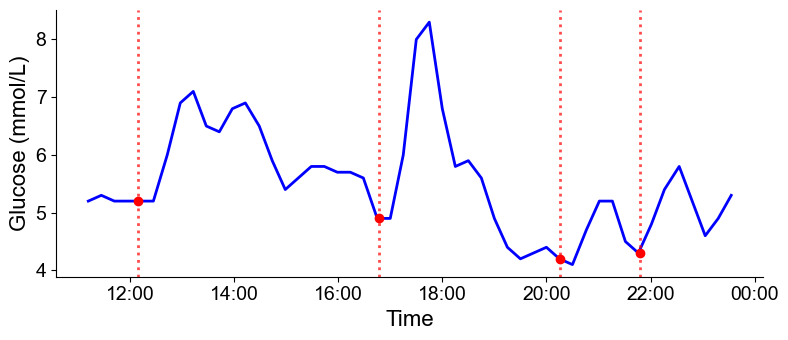

In [19]:
import matplotlib.dates as mdates

user_id = 1609  # np.random.choice(df_gluc["id"].unique())  # 150 640:715 # 2389 200:255 # 1609 220:250

# Make a lineplot with time on x and gl_mmol on y
plot_gluc = df_gluc[df_gluc["id"] == user_id].sort_values(by="time")[200:250]
plot_gluc = plot_gluc.reset_index(drop=True)
plot_gluc["time"] = plot_gluc["time"] + pd.Timedelta(hours=2)

time_extent = (plot_gluc["time"].iloc[0], plot_gluc["time"].iloc[-1])

meal_occurences_df = model_data[
    (model_data["subject_key"] == meta[meta["id"] == user_id]["subject_key"].values[0])
    & (model_data["local_eaten_at"] > time_extent[0])
    & (model_data["local_eaten_at"] < time_extent[1])
    & (model_data["carb_eaten"] > 5)
]

meal_occurences = meal_occurences_df["local_eaten_at"].values  # + pd.Timedelta(hours=1)

plt.figure(figsize=(8, 3.5))
plt.plot(
    plot_gluc["time"],
    plot_gluc["gl_mmol"],
    label="Glucose curve",
    linestyle="-",
    markersize=2,
    linewidth=2,
    color="blue",
)

# Keep handles for legend
dot_handles = []

for i, meal_time in enumerate(meal_occurences):
    meal_time = pd.to_datetime(meal_time)
    plt.axvline(meal_time, color="red", linestyle=":", alpha=0.7, linewidth=2)

    # Find the intersection point for the red dot
    nearest_idx = (plot_gluc["time"] - meal_time).abs().idxmin()
    intersect_y = plot_gluc.loc[nearest_idx, "gl_mmol"]

    h2 = plt.scatter(
        [meal_time],
        [intersect_y],
        color="red",
        zorder=5,
        label="Meal occurrence" if i == 0 else "",
    )
    dot_handles.append(h2)

print("user_id:", user_id)

plt.xlabel("Time", fontsize=16)
plt.ylabel("Glucose (mmol/L)", fontsize=16)

# Add legend
# plt.legend(loc="upper right", frameon=True, bbox_to_anchor=(0.9, 1))

# Format the x-axis to show only hours and minutes, not date
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# Increase x and y axis tick font size
ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()
sns.despine()

plt.savefig(
    "../images/fig4/glucose_curve_MT180.png",
    dpi=300,
    bbox_inches="tight",
)